In [8]:
import sys
!{sys.executable} -m pip install pandas


In [9]:
import sys
!{sys.executable} -m pip install matplotlib
import matplotlib.pyplot as plt

In [15]:
import sys
!{sys.executable} -m pip install numpy
import numpy as np

In [10]:
import sys
!{sys.executable} -m pip install seaborn
import seaborn as sns

In [11]:
import sys
!{sys.executable} -m pip install scikit-learn

### Датасет

Для задачи взят датасет [Forest Cover Type Dataset](https://www.kaggle.com/datasets/uciml/forest-cover-type-dataset), который численно описывает различные виды деревьев и местность в национальном лесу Рузвельт (Колорадо, США). Все измерения сделаны для секций 30х30 кв.м. Данные собраны государственным университетом Колорадо.

In [ ]:
import pandas as pd

df = pd.read_csv("covtype.csv")

In [ ]:
y_true = df["Cover_Type"]
df = df.drop(columns=["Cover_Type"])
df.head()

### EDA

In [159]:
df.shape

(581012, 54)

In [160]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 581012 entries, 0 to 581011
Data columns (total 54 columns):
 #   Column                              Non-Null Count   Dtype
---  ------                              --------------   -----
 0   Elevation                           581012 non-null  int64
 1   Aspect                              581012 non-null  int64
 2   Slope                               581012 non-null  int64
 3   Horizontal_Distance_To_Hydrology    581012 non-null  int64
 4   Vertical_Distance_To_Hydrology      581012 non-null  int64
 5   Horizontal_Distance_To_Roadways     581012 non-null  int64
 6   Hillshade_9am                       581012 non-null  int64
 7   Hillshade_Noon                      581012 non-null  int64
 8   Hillshade_3pm                       581012 non-null  int64
 9   Horizontal_Distance_To_Fire_Points  581012 non-null  int64
 10  Wilderness_Area1                    581012 non-null  int64
 11  Wilderness_Area2                    581012 non-null  int64
 12 

Датасет содержит 581012 объектов и 54 признака. Все признаки имеют числовой тип. 

In [161]:
df.describe()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type31,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40
count,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,...,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000,581012.000000
mean,2959.365301,155.656807,14.103704,269.428217,46.418855,2350.146611,212.146049,223.318716,142.528263,1980.291226,...,0.044175,0.090392,0.077716,0.002773,0.003255,0.000205,0.000513,0.026803,0.023762,0.015060
std,279.984734,111.913721,7.488242,212.549356,58.295232,1559.254870,26.769889,19.768697,38.274529,1324.195210,...,0.205483,0.286743,0.267725,0.052584,0.056957,0.014310,0.022641,0.161508,0.152307,0.121791
min,1859.000000,0.000000,0.000000,0.000000,-173.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2809.000000,58.000000,9.000000,108.000000,7.000000,1106.000000,198.000000,213.000000,119.000000,1024.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,2996.000000,127.000000,13.000000,218.000000,30.000000,1997.000000,218.000000,226.000000,143.000000,1710.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,3163.000000,260.000000,18.000000,384.000000,69.000000,3328.000000,231.000000,237.000000,168.000000,2550.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,3858.000000,360.000000,66.000000,1397.000000,601.000000,7117.000000,254.000000,254.000000,254.000000,7173.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


В ходе анализа статистик признаков было выявлено, что признаки имеют различные масштабы значений. Наблюдается значительный разброс между минимальными и максимальными значениями. Необходимо нормализовать данные перед применением алгоритмов кластеризации.

#### Обработка пропущенных значений

In [162]:
df.isnull().sum()

Elevation                             0
Aspect                                0
Slope                                 0
Horizontal_Distance_To_Hydrology      0
Vertical_Distance_To_Hydrology        0
Horizontal_Distance_To_Roadways       0
Hillshade_9am                         0
Hillshade_Noon                        0
Hillshade_3pm                         0
Horizontal_Distance_To_Fire_Points    0
Wilderness_Area1                      0
Wilderness_Area2                      0
Wilderness_Area3                      0
Wilderness_Area4                      0
Soil_Type1                            0
Soil_Type2                            0
Soil_Type3                            0
Soil_Type4                            0
Soil_Type5                            0
Soil_Type6                            0
Soil_Type7                            0
Soil_Type8                            0
Soil_Type9                            0
Soil_Type10                           0
Soil_Type11                           0


Пропущенных значений нет, информация полная.

#### Анализ распределений

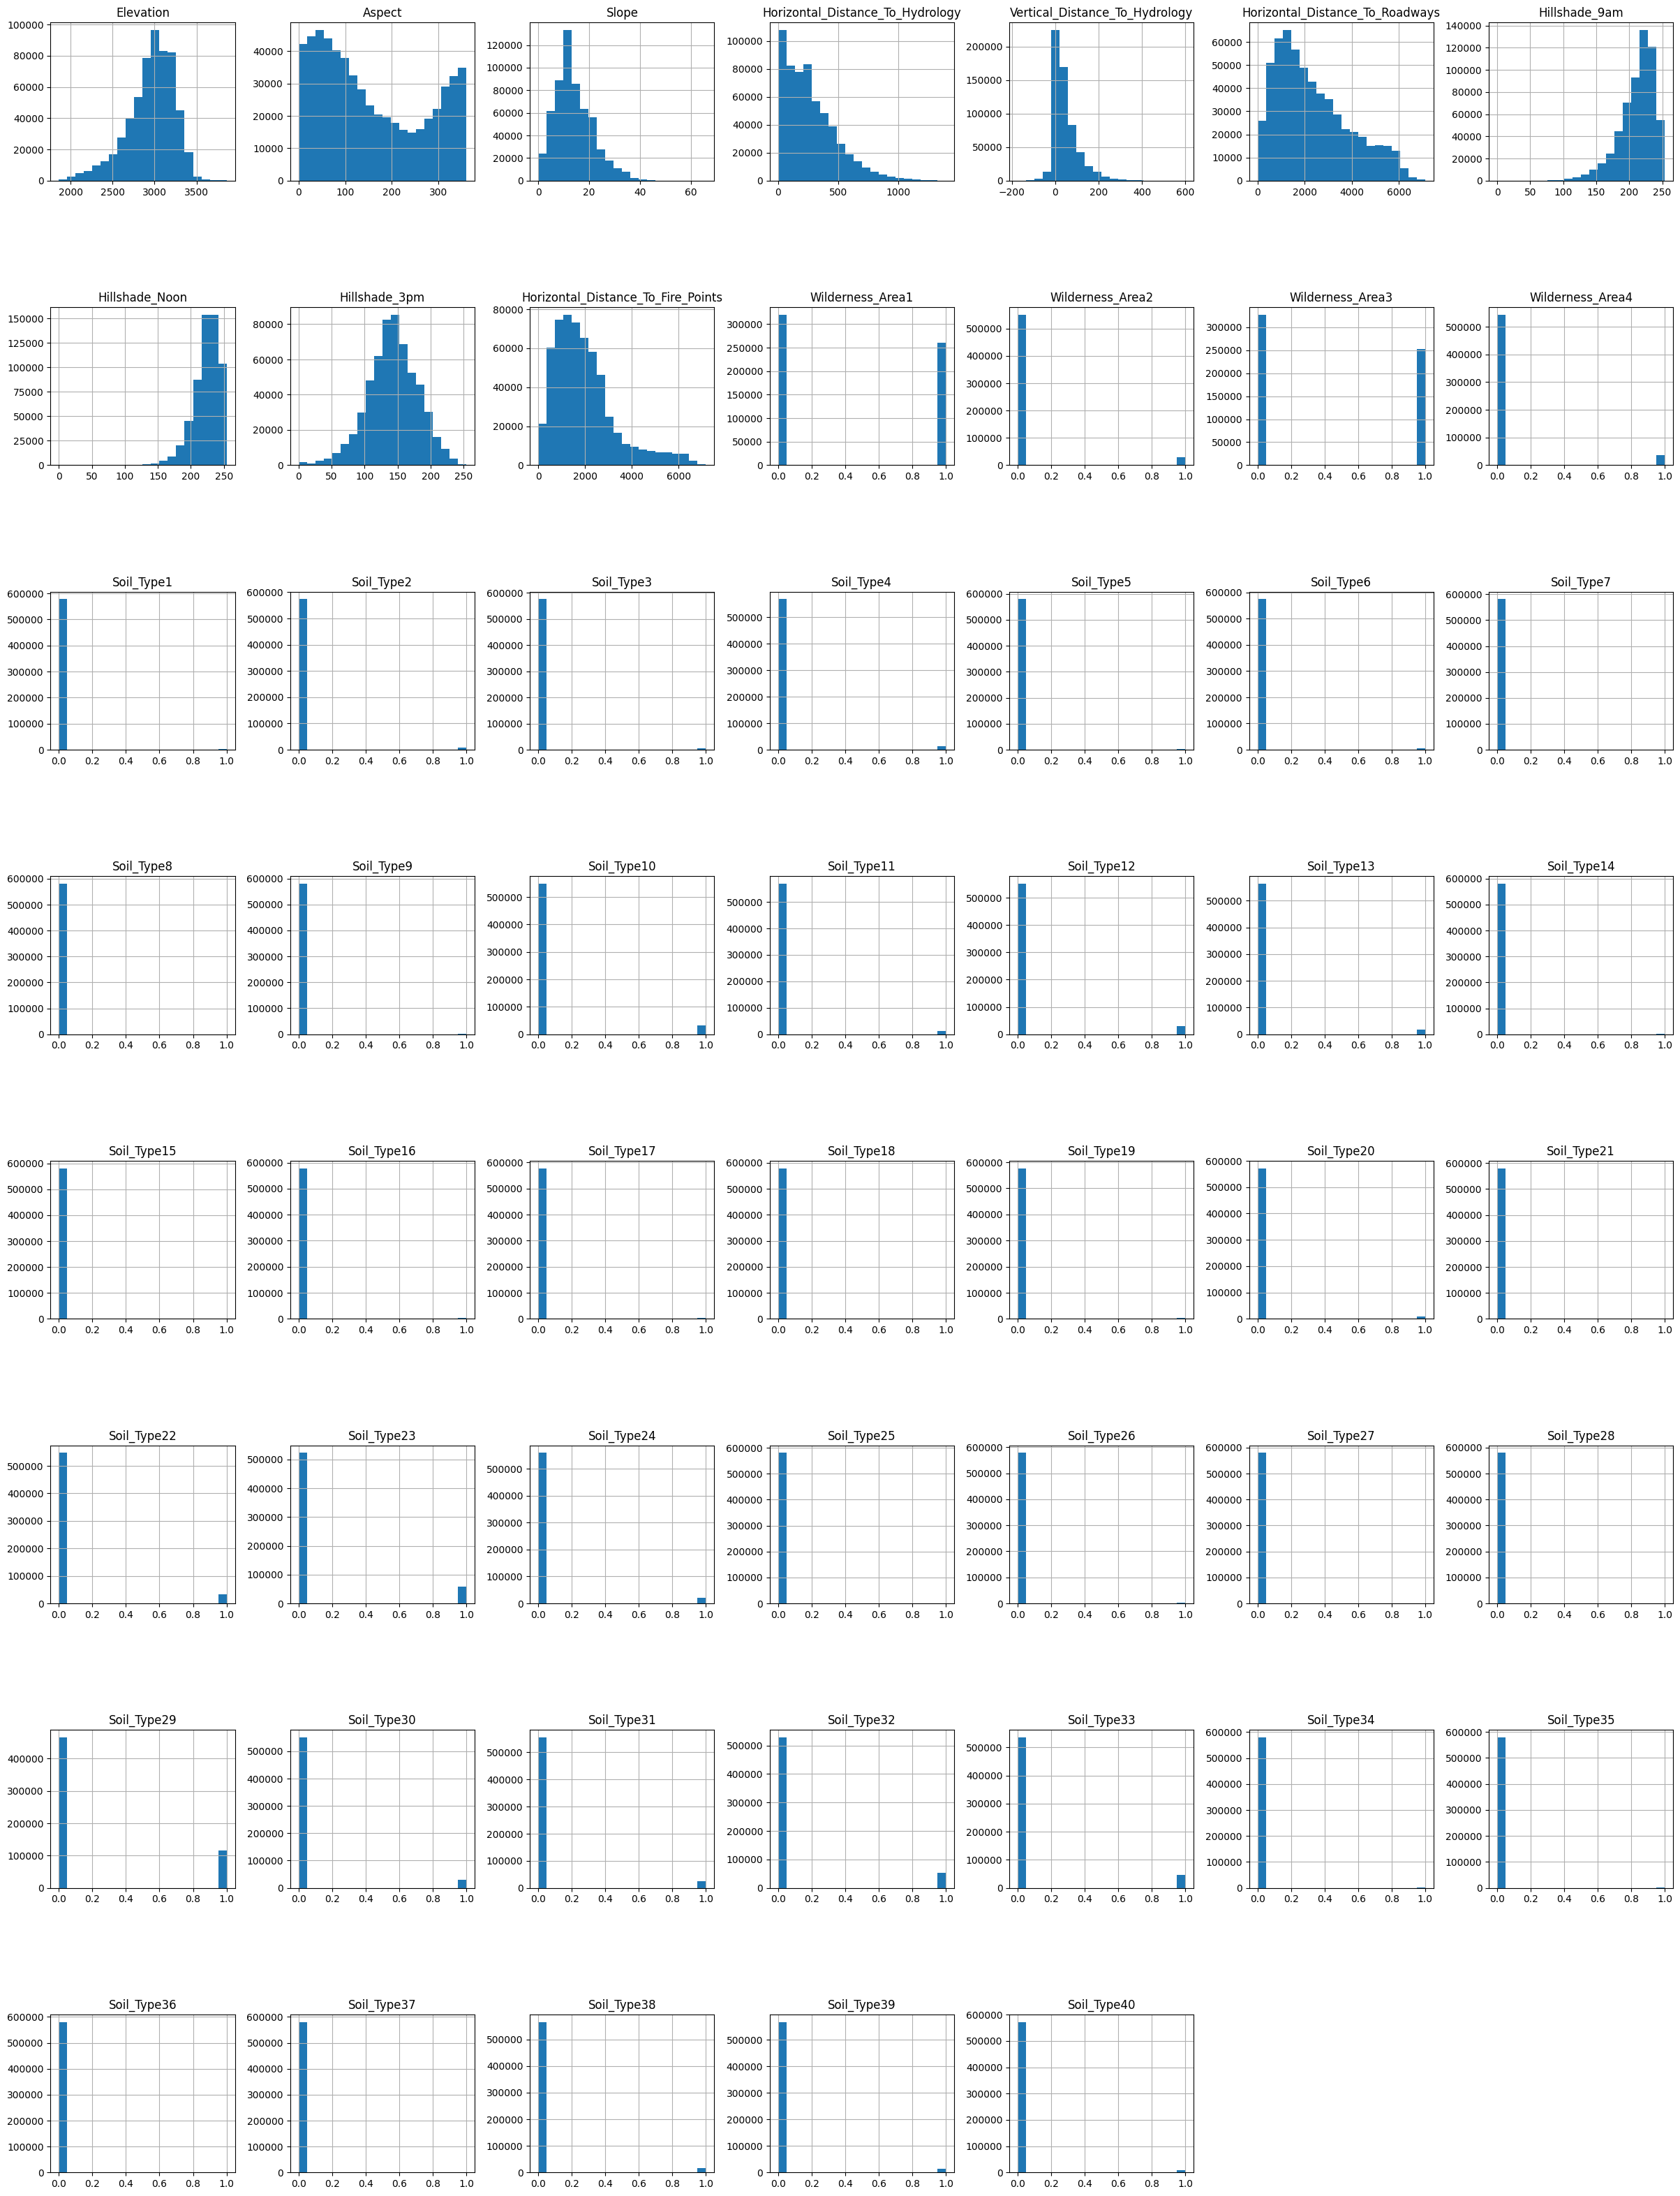

In [163]:
df.hist(figsize=(30, 40), bins=20)

plt.subplots_adjust(hspace=0.8)
plt.show()

Анализ гистограмм показал, что в данных присутствует большое количество бинарных признаков (принимающих значения 0 и 1). 
Также наблюдаются признаки с несимметричным распределением и различной формой распределений, что указывает на неоднородность данных. Дополнительные преобразования распределений не проведены, поскольку они не являются обязательными для кластеризации.


#### Корреляция

Помогает оценить связи между признаками:\
+1 → сильная положительная связь\
-1 → сильная отрицательная\
&nbsp;0 → связи нет

Тепловая карта для наглядности

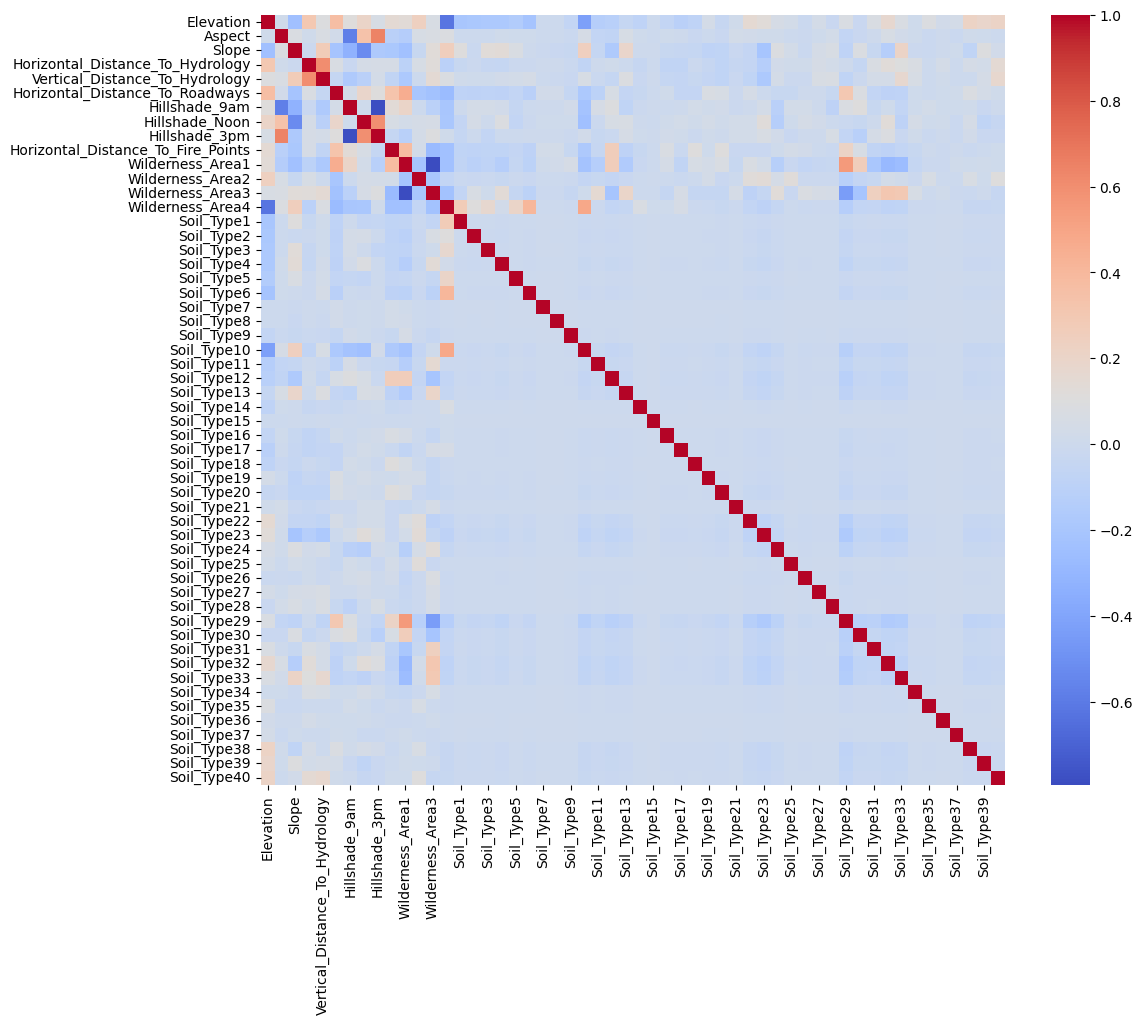

In [164]:
corr = df.corr()
plt.figure(figsize=(12, 10))
sns.heatmap(corr, cmap='coolwarm')
plt.show()

In [165]:
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high_corr_pairs = upper.stack().sort_values(ascending=False)
print(high_corr_pairs[high_corr_pairs > 0.8])

Series([], dtype: float64)


Анализ корреляционной матрицы показал отсутствие признаков с высокой линейной зависимостью (коэффициент корреляции > 0.8). 
Это свидетельствует о том, что признаки содержат различную информацию и не являются избыточными.

In [5]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X = scaler.fit_transform(df)

Для корректной работы алгоритмов кластеризации была выполнена нормализация признаков с использованием StandardScaler. 
Это позволило привести все признаки к единому масштабу.

### Алгоритм кластеризации K-means

Изначально в датасете указано 7 типов лесистости. Не будем ипользовать эту информацию при обучении, только при сравнении работы различных алгоритмов кластеризации.

In [6]:
class MyKMeans:
    def __init__(self, n_clusters=2, max_iter=100, tol=1e-4, random_state=42):
        self.n_clusters = n_clusters
        self.max_iter = max_iter
        self.tol = tol
        self.random_state = random_state

    def _init_centroids_kmeans_pp(self, X):
        np.random.seed(self.random_state)
    
        n_samples = X.shape[0]
        centroids = []
    
        # первый центр — случайный
        idx = np.random.randint(n_samples)
        centroids.append(X[idx])
    
        # остальные центры - с вероятностью, пропорциональной расстоянию до ближайшего уже выбранного центра
        for _ in range(1, self.n_clusters):
            distances = np.array([
                min(np.linalg.norm(x - c)**2 for c in centroids)
                for x in X
            ])
    
            probs = distances / distances.sum()
            idx = np.random.choice(n_samples, p=probs)
            centroids.append(X[idx])
    
        return np.array(centroids)

    def fit(self, X):
        if isinstance(X, pd.DataFrame):
            X = X.to_numpy()
        np.random.seed(self.random_state)

        # инициализация центроидов через k-means++
        self.centroids = self._init_centroids_kmeans_pp(X)
        # self.centroids = X[np.random.choice(X.shape[0], self.n_clusters, replace=False)]

        for i in range(self.max_iter):
            # считаем расстояния до центров
            distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
            # назначаем кластеры
            labels = np.argmin(distances, axis=1)

            # пересчитываем центры
            new_centroids = np.array([
                X[labels == k].mean(axis=0) if np.any(labels == k) else self.centroids[k]
                for k in range(self.n_clusters)
            ])

            # проверка сходимости
            shift = np.linalg.norm(self.centroids - new_centroids)

            self.centroids = new_centroids

            if shift < self.tol:
                break

        self.labels_ = labels
        return self

    def predict(self, X):
        distances = np.linalg.norm(X[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

#### Найдем оптимальное количество кластеров

Посчитаем silhouette score

In [179]:
from sklearn.metrics import silhouette_score

scores = []

k_values = range(2, 11)

for k in k_values:
    model = MyKMeans(n_clusters=k, random_state=42)
    model.fit(X)

    score = silhouette_score(X, model.labels_, metric="euclidean", sample_size=10000)
    print(
        "Для n_clusters =",
        k,
        "silhouette score :",
        score,
    )
    scores.append(score)

best_k = k_values[np.argmax(scores)]
print("Лучшее k:", best_k)

Для n_clusters = 2 silhouette score : 0.09130617863296589
Для n_clusters = 3 silhouette score : 0.09277999759636514
Для n_clusters = 4 silhouette score : 0.10160443372679481
Для n_clusters = 5 silhouette score : 0.11001429402551857
Для n_clusters = 6 silhouette score : 0.11474688394943341
Для n_clusters = 7 silhouette score : 0.12376289156107395
Для n_clusters = 8 silhouette score : 0.13421812684308335
Для n_clusters = 9 silhouette score : 0.10821726505128877
Для n_clusters = 10 silhouette score : 0.11187792753196042
Лучшее k: 8


Таким образом, алгоритм лучше всего разделил данные на 8 кластеров. Посмотрим на распределение кластеров

In [ ]:
my_kmeans = MyKMeans(n_clusters=8)
my_kmeans.fit(X)
unique, counts = np.unique(my_kmeans.labels_, return_counts=True)

print(dict(zip(unique, counts)))

### Обучение моделей кластеризации

Возьмем для сравнения метрик качества реализованный алгоритм кластеризации и k-means, DBSCAN из `scikit-learn`

In [14]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=7, init = 'k-means++', max_iter = 100, random_state=42)

Для алгоритма DBSCAN подберем eps и min_samples

In [17]:
from sklearn.cluster import DBSCAN

dbscan_results = []

for eps in [0.3, 0.5, 0.7, 1.0]:
    for min_samples in [3, 5, 10]:
        print(eps)
        print(min_samples)
        model = DBSCAN(eps=eps, min_samples=min_samples, n_jobs=-1)
        model.fit(X)
        print(min_samples)
        labels = model.labels_

        # проверка (DBSCAN может дать 1 кластер)
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels, metric="euclidean", sample_size=5000)
        else:
            score = -1
        print(min_samples)

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "score": score
        })

0.3
3


KeyboardInterrupt: 

In [ ]:
import pandas as pd

df_db = pd.DataFrame(dbscan_results)

best_dbscan_params = df_db.sort_values(by="score", ascending=False).iloc[0]

print(best_dbscan_params)

In [ ]:
model = DBSCAN(n_jobs=-1)
start = time.time()
model.fit(X[:2000])
end = time.time()

In [ ]:
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    v_measure_score
)

results = []

def evaluate_model(name, model, X, y_true):
    start = time.time()
    
    labels = model.fit_predict(X)
    
    end = time.time()
    
    results.append({
        "model": name,
        "time": end - start,
        "ARI": adjusted_rand_score(y_true, labels),
        "NMI": normalized_mutual_info_score(y_true, labels),
        "V-measure": v_measure_score(y_true, labels)
    })

Для оценки качества кластеризации использовались внешние метрики: Adjusted Rand Index (ARI), Normalized Mutual Information (NMI) и V-measure. Также измерялось время обучения моделей.
* ARI показывает, насколько правильно объекты распределены по кластерам относительно истинной разметки
* NMI показывает, насколько хорошо кластеры сохраняют информацию о реальных классах
* V-measure -- гармоническое среднее двух показателей:
  * Homogeneity — насколько каждый кластер содержит объекты одного класса
  * Completeness — насколько все объекты одного класса попали в один кластер

In [ ]:
evaluate_model("MyKMeans", MyKmeans(k=7), X, y_true)
evaluate_model("KMeans", kmeans, X, y_true)
evaluate_model("DBSCAN", DBSCAN(eps=best_eps, min_samples=best_min_samples), X, y_true)

In [ ]:
df_final = pd.DataFrame(results)
print(df_final)

In [ ]:
plt.figure()
plt.bar(df_final["model"], df_final["time"])
plt.title("Training Time")
plt.ylabel("seconds")
plt.show()

In [ ]:
plt.figure()
plt.bar(df_final["model"], df_final["ARI"])
plt.title("Adjusted Rand Index")
plt.show()

In [ ]:
plt.figure()
plt.bar(df_final["model"], df_final["NMI"])
plt.title("Normalized Mutual Information")
plt.show()

In [ ]:
plt.figure()
plt.bar(df_final["model"], df_final["V-measure"])
plt.title("V-measure")
plt.show()